In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Numerical Verification of the Linear Model

We verify the analytical results from the **Linear Model** section, following the framework of:

> Elhage et al. (2022). *Toy Models of Superposition*. Transformer Circuits Thread.  
> https://transformer-circuits.pub/2022/toy_model/index.html

**Setup:** $n=2$, $m=1$ — two features projected to one dimension.

$$h = wx, \quad x' = w^Th + b = (w^Tw)\,x + b, \quad w = (\cos\theta,\, \sin\theta)$$

Each $x_{Ji}$ is $0$ with probability $1-p_i$, otherwise $\sim \mathrm{Uniform}[0,1]$. The loss is a weighted MSE averaged over $k$ training samples:

$$\mathcal{L} = \frac{1}{2k}\sum_{J=1}^{k}\sum_{i} I_i\,(x_{Ji} - x'_{Ji})^2$$

For $k\gg 1$ the loss concentrates around its mean, so we study $E[\mathcal{L}]$.

**We verify:**
1. $E[\mathcal{L}]$ analytical formula vs Monte Carlo
2. Optimal biases $b^*$ (analytical) vs numerical minimisation
3. Loss landscape $E[\mathcal{L}]|_{b^*}(\theta)$ vs Monte Carlo sweep
4. Second-derivative analysis: $\theta=0,\,\pi/2$ are the only minima; the non-trivial critical point $\theta^*$ is always a saddle

In [2]:
# ── simple minimizer (no scipy needed) ────────────────────────────────────────

def minimize_1d(f, a, b, tol=1e-10):
    """Golden-section search for the minimum of f on [a, b]."""
    gr = (np.sqrt(5) + 1) / 2
    c = b - (b - a) / gr
    d = a + (b - a) / gr
    while abs(b - a) > tol:
        if f(c) < f(d):
            b = d
        else:
            a = c
        c = b - (b - a) / gr
        d = a + (b - a) / gr
    return (a + b) / 2

def minimize_2d(f, x0, lr=1e-3, steps=5000):
    """Simple gradient descent via finite differences for 2D."""
    x = np.array(x0, dtype=float)
    eps = 1e-7
    for _ in range(steps):
        grad = np.zeros(2)
        for i in range(2):
            xp = x.copy(); xp[i] += eps
            xm = x.copy(); xm[i] -= eps
            grad[i] = (f(xp) - f(xm)) / (2*eps)
        x -= lr * grad
    return x

# ── helpers ───────────────────────────────────────────────────────────────────

def sample_x(k, p1, p2):
    """Draw k i.i.d. samples of x = (x1, x2)."""
    on  = np.random.binomial(1, [p1, p2], size=(k, 2)).astype(float)
    val = np.random.uniform(0, 1, size=(k, 2))
    return on * val                                    # shape (k, 2)

def wTw(theta):
    """Return the 2×2 matrix w^T w for w = [cos θ, sin θ]."""
    c, s = np.cos(theta), np.sin(theta)
    return np.array([[c**2,   c*s],
                     [c*s,    s**2]])

def loss_samples(X, theta, b, I1, I2):
    """
    Compute the mean loss  L = (1/2) mean_J Σ_i I_i (x_i - x'_i)²
    where x' = (w^T w) x + b.
    """
    W = wTw(theta)
    Xp = X @ W.T + b                                   # (k,2)  reconstructed
    I  = np.array([I1, I2])
    return 0.5 * np.mean(np.sum(I * (X - Xp)**2, axis=1))

# ── analytical formulas ───────────────────────────────────────────────────────

def E_L_analytical(theta, b1, b2, p1, p2, I1, I2):
    """
    E[L] from the closed-form expression (eq. 78–83 in the notes).
    """
    c  = np.cos(theta);  s  = np.sin(theta)
    s2 = np.sin(2*theta)
    return (
        (1/6)*I1*s**4*p1 + (1/6)*I2*c**4*p2
        + s2**2/24 * (I1*p2 + I2*p1)
        + 0.5*(I1*b1**2 + I2*b2**2)
        - s2/8*(I1*s**2 + I2*c**2)*p1*p2
        - 0.5*(I1*s**2*b1*p1 + I2*c**2*b2*p2)
        + s2/4*(I1*p2*b1 + I2*p1*b2)
    )

def b_star(theta, p1, p2):
    """
    Analytically optimal biases (eq. 87–88):
      b1* = (sin θ / 2)(p1 sin θ − p2 cos θ)
      b2* = (cos θ / 2)(p2 cos θ − p1 sin θ)
    """
    c, s = np.cos(theta), np.sin(theta)
    b1 = (s/2)*(p1*s - p2*c)
    b2 = (c/2)*(p2*c - p1*s)
    return b1, b2

def E_L_opt(theta, p1, p2, I1, I2):
    """
    E[L] evaluated at the optimal biases b* (eq. 92):
      = (1/6)(I1 p1 s^4 + I2 p2 c^4)
        + s_{2θ}²/24 (I1 p2 + I2 p1)
        − (I1 s² + I2 c²)(p1² s² + p2² c²)/8
    """
    c  = np.cos(theta);  s  = np.sin(theta)
    s2 = np.sin(2*theta)
    return (
        (1/6)*(I1*p1*s**4 + I2*p2*c**4)
        + s2**2/24*(I1*p2 + I2*p1)
        - (I1*s**2 + I2*c**2)*(p1**2*s**2 + p2**2*c**2)/8
    )

print("Helper functions defined.")


Helper functions defined.


## 1. Validating the expected loss formula

Since $x_i$ is either $0$ (with probability $1-p_i$) or $\mathrm{Uniform}[0,1]$ (with probability $p_i$), its moments are $E[x_i]=p_i/2$ and $E[x_i^2]=p_i/3$. Expanding the squared loss and taking expectations (using independence of $x_1, x_2$) yields the closed form:

$$E[\mathcal{L}] = \frac{I_1 p_1 s_\theta^4}{6} + \frac{I_2 p_2 c_\theta^4}{6} + \frac{s_{2\theta}^2}{24}(I_1 p_2 + I_2 p_1) + \frac{1}{2}\!\sum_i I_i b_i^2 - \frac{s_{2\theta}}{8}(I_1 s_\theta^2 + I_2 c_\theta^2)p_1 p_2 - \frac{1}{2}(I_1 s_\theta^2 b_1 p_1 + I_2 c_\theta^2 b_2 p_2) + \frac{s_{2\theta}}{4}(I_1 p_2 b_1 + I_2 p_1 b_2).$$

We verify this against Monte Carlo across 8 random parameter configurations.

In [3]:

# =============================================================================
# 1. Validate E[L] analytical formula against Monte Carlo
# =============================================================================
# We check across several random (θ, b1, b2, p1, p2, I1, I2) configurations.

np.random.seed(42)
k = 500_000            # large sample for tight Monte Carlo estimate

print(f"{'θ':>6}  {'p1':>4}  {'p2':>4}  {'I1':>4}  {'I2':>4}  "
      f"{'MC E[L]':>12}  {'Analytical':>12}  {'rel error':>10}")
print("-" * 75)

for _ in range(8):
    theta = np.random.uniform(0, np.pi/2)
    p1, p2 = np.random.uniform(0.1, 0.9, 2)
    I1, I2 = np.random.uniform(0.5, 2.0, 2)
    b1 = np.random.uniform(-0.2, 0.2)
    b2 = np.random.uniform(-0.2, 0.2)

    X   = sample_x(k, p1, p2)
    mc  = loss_samples(X, theta, [b1, b2], I1, I2)
    ana = E_L_analytical(theta, b1, b2, p1, p2, I1, I2)
    rel = abs(mc - ana) / (ana + 1e-12)

    print(f"{theta:6.3f}  {p1:.2f}  {p2:.2f}  {I1:.2f}  {I2:.2f}  "
          f"{mc:12.6f}  {ana:12.6f}  {rel:10.2e}")


     θ    p1    p2    I1    I2       MC E[L]    Analytical   rel error
---------------------------------------------------------------------------
 0.588  0.86  0.69  1.40  0.73      0.076322      0.076519    2.58e-03
 1.288  0.82  0.21  0.73  0.96      0.066855      0.066766    1.32e-03
 1.045  0.75  0.46  1.59  0.89      0.137491      0.137856    2.65e-03
 1.481  0.44  0.76  0.81  1.05      0.102192      0.102383    1.87e-03
 0.923  0.32  0.78  0.84  0.87      0.087856      0.088047    2.17e-03
 1.381  0.71  0.75  1.45  0.63      0.139755      0.139388    2.63e-03
 0.881  0.34  0.26  1.12  1.26      0.050213      0.050254    7.98e-04
 0.696  0.13  0.14  0.53  0.56      0.019613      0.019593    9.88e-04


## 2. Validating the optimal biases $b^*$

Given an angle $\theta$, the loss $E[\mathcal{L}]$ is a sum of independent quadratics in $b_1$ and $b_2$.  
Setting $\partial E[\mathcal{L}]/\partial b_i = 0$ yields closed-form optimal biases

$$
b_i^*(\theta) = -\frac{p_i}{2}\bigl(w^\top w\bigr)_{ii},
$$

where $(w^\top w)_{ii}$ is the $i$-th diagonal entry of the weight Gram matrix.  
Below we sweep $\theta \in [0, \pi/2]$ and compare the analytical $b_i^*$ against the numerically minimised biases (gradient descent), reporting both absolute and relative errors.

In [4]:

# =============================================================================
# 2. Validate optimal biases b* against numerical minimisation
# =============================================================================

print(f"{'θ':>6}  {'p1':>4}  {'p2':>4}  "
      f"{'b1* analytic':>14}  {'b1* numeric':>12}  {'rel err b1':>11}  "
      f"{'b2* analytic':>14}  {'b2* numeric':>12}  {'rel err b2':>11}")
print("-" * 100)

for _ in range(8):
    theta = np.random.uniform(0, np.pi/2)
    p1, p2 = np.random.uniform(0.1, 0.9, 2)
    I1, I2 = np.random.uniform(0.5, 2.0, 2)

    def obj(b):
        return E_L_analytical(theta, b[0], b[1], p1, p2, I1, I2)

    b_num = minimize_2d(obj, [0.0, 0.0])
    b1n, b2n = b_num
    b1a, b2a = b_star(theta, p1, p2)

    rel1 = abs(b1n - b1a) / (abs(b1a) + 1e-12)
    rel2 = abs(b2n - b2a) / (abs(b2a) + 1e-12)

    print(f"{theta:6.3f}  {p1:.2f}  {p2:.2f}  "
          f"{b1a:14.8f}  {b1n:12.8f}  {rel1:11.2e}  "
          f"{b2a:14.8f}  {b2n:12.8f}  {rel2:11.2e}")


     θ    p1    p2    b1* analytic   b1* numeric   rel err b1    b2* analytic   b2* numeric   rel err b2
----------------------------------------------------------------------------------------------------
 1.407  0.28  0.57      0.09275079    0.08539130     7.93e-02     -0.01533805   -0.01532230     1.03e-03
 1.083  0.56  0.87      0.03801718    0.03524352     7.30e-02     -0.02017706   -0.01912453     5.22e-02
 0.917  0.44  0.31      0.06298837    0.06297185     2.62e-04     -0.04826674   -0.04824773     3.94e-04
 0.880  0.19  0.33     -0.02548020   -0.02546538     5.82e-04      0.02107574    0.02106545     4.89e-04
 0.988  0.69  0.69      0.08173047    0.08172639     4.99e-05     -0.05385541   -0.05371101     2.68e-03
 0.224  0.30  0.35     -0.02983712   -0.02957841     8.67e-03      0.13106878    0.13106167     5.42e-05
 1.562  0.66  0.25      0.33085890    0.33050893     1.06e-03     -0.00306743   -0.00306714     9.60e-05
 0.285  0.51  0.70     -0.07479812   -0.07119598     4.82e-

## 3. Loss landscape and convergence

Substituting $b^*(\theta)$ back into $E[\mathcal{L}]$ gives the **reduced loss**

$$
E[\mathcal{L}]\big|_{b^*}(\theta),
$$

which is a function of $\theta$ alone.  One can show analytically that this function has **no interior minima** in $(0, \pi/2)$: any critical point $\theta^*$ satisfying $\sin(2\theta^*) \neq 0$ is necessarily a saddle, not a minimum.  The global minimum therefore always sits at one of the endpoints $\theta = 0$ or $\theta = \pi/2$, corresponding to the network representing exactly one of the two features — no superposition.

Below we plot the landscape and validate the Monte Carlo estimator against the analytical curve, showing how the residual shrinks as the sample size increases from 5 k → 50 k → 500 k (expected $1/\sqrt{k}$ convergence).

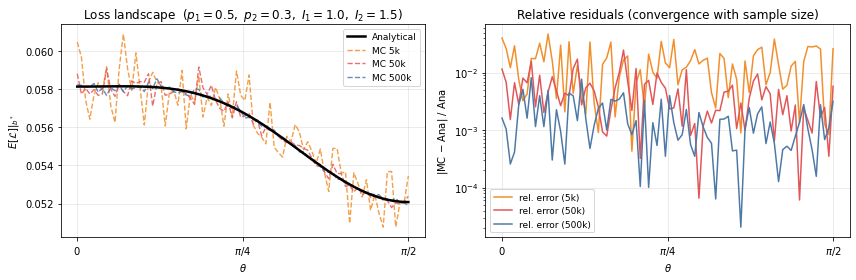

k=   5k  max rel error: 4.70e-02  mean rel error: 1.53e-02
k=  50k  max rel error: 2.47e-02  mean rel error: 4.79e-03
k= 500k  max rel error: 8.18e-03  mean rel error: 1.73e-03


In [5]:

# =============================================================================
# 3. Loss landscape E[L]|_{b*}(θ): analytical vs Monte Carlo sweep
# =============================================================================
# Generate 500k points once per θ, then slice for 50k and 5k — no redundant
# sampling.  The residual plot shows convergence across the three sizes.

p1, p2 = 0.5, 0.3
I1, I2 = 1.0, 1.5

K_MAX  = 500_000
ks     = [5_000, 50_000, 500_000]
labels = ['5k', '50k', '500k']
colors = ['#f28e2b', '#e15759', '#4e79a7']   # orange → red → blue

thetas   = np.linspace(0, np.pi/2, 80)
ana_vals = np.array([E_L_opt(th, p1, p2, I1, I2) for th in thetas])

np.random.seed(0)
mc_by_k = {k: [] for k in ks}

for th in thetas:
    b1, b2 = b_star(th, p1, p2)
    X = sample_x(K_MAX, p1, p2)          # draw 500k once, slice for smaller k
    for k in ks:
        mc_by_k[k].append(loss_samples(X[:k], th, [b1, b2], I1, I2))

mc_by_k = {k: np.array(v) for k, v in mc_by_k.items()}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# left: analytical curve + all three MC curves
ax = axes[0]
ax.plot(thetas, ana_vals, 'k-', lw=2.5, label='Analytical', zorder=5)
for k, lbl, col in zip(ks, labels, colors):
    ax.plot(thetas, mc_by_k[k], '--', color=col, lw=1.4, alpha=0.85,
            label=f'MC {lbl}')
ax.set_xlabel(r'$\theta$')
ax.set_ylabel(r'$E[\mathcal{L}]|_{b^*}$')
ax.set_title(f'Loss landscape  ($p_1={p1},\\ p_2={p2},\\ I_1={I1},\\ I_2={I2}$)')
ax.set_xticks([0, np.pi/4, np.pi/2])
ax.set_xticklabels(['$0$', r'$\pi/4$', r'$\pi/2$'])
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# right: RELATIVE residuals (log scale) — |MC − Ana| / Ana
ax = axes[1]
for k, lbl, col in zip(ks, labels, colors):
    rel_err = np.abs(mc_by_k[k] - ana_vals) / (ana_vals + 1e-15)
    ax.plot(thetas, rel_err, color=col, lw=1.5,
            label=f'rel. error ({lbl})')
ax.set_xlabel(r'$\theta$')
ax.set_ylabel(r'$|$MC $-$ Ana$|\ /\ $Ana')
ax.set_title('Relative residuals (convergence with sample size)')
ax.set_xticks([0, np.pi/4, np.pi/2])
ax.set_xticklabels(['$0$', r'$\pi/4$', r'$\pi/2$'])
ax.set_yscale('log')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('loss_landscape.png', dpi=120)
plt.show()

for k, lbl in zip(ks, labels):
    rel = np.abs(mc_by_k[k] - ana_vals) / (ana_vals + 1e-15)
    print(f'k={lbl:>5s}  max rel error: {np.max(rel):.2e}'
          f'  mean rel error: {np.mean(rel):.2e}')


## 4. Interactive loss landscape

Drag the sliders to explore how $E[\mathcal{L}]|_{b^*}(\theta)$ changes with all four parameters. The labelled dots mark the two trivial critical points $\theta=0$ and $\theta=\pi/2$, and the top-left label tracks which is the global minimum.

*Requires `%matplotlib notebook` (classic Jupyter) or `%matplotlib widget` with `ipympl` (JupyterLab).*

<IPython.core.display.Javascript object>


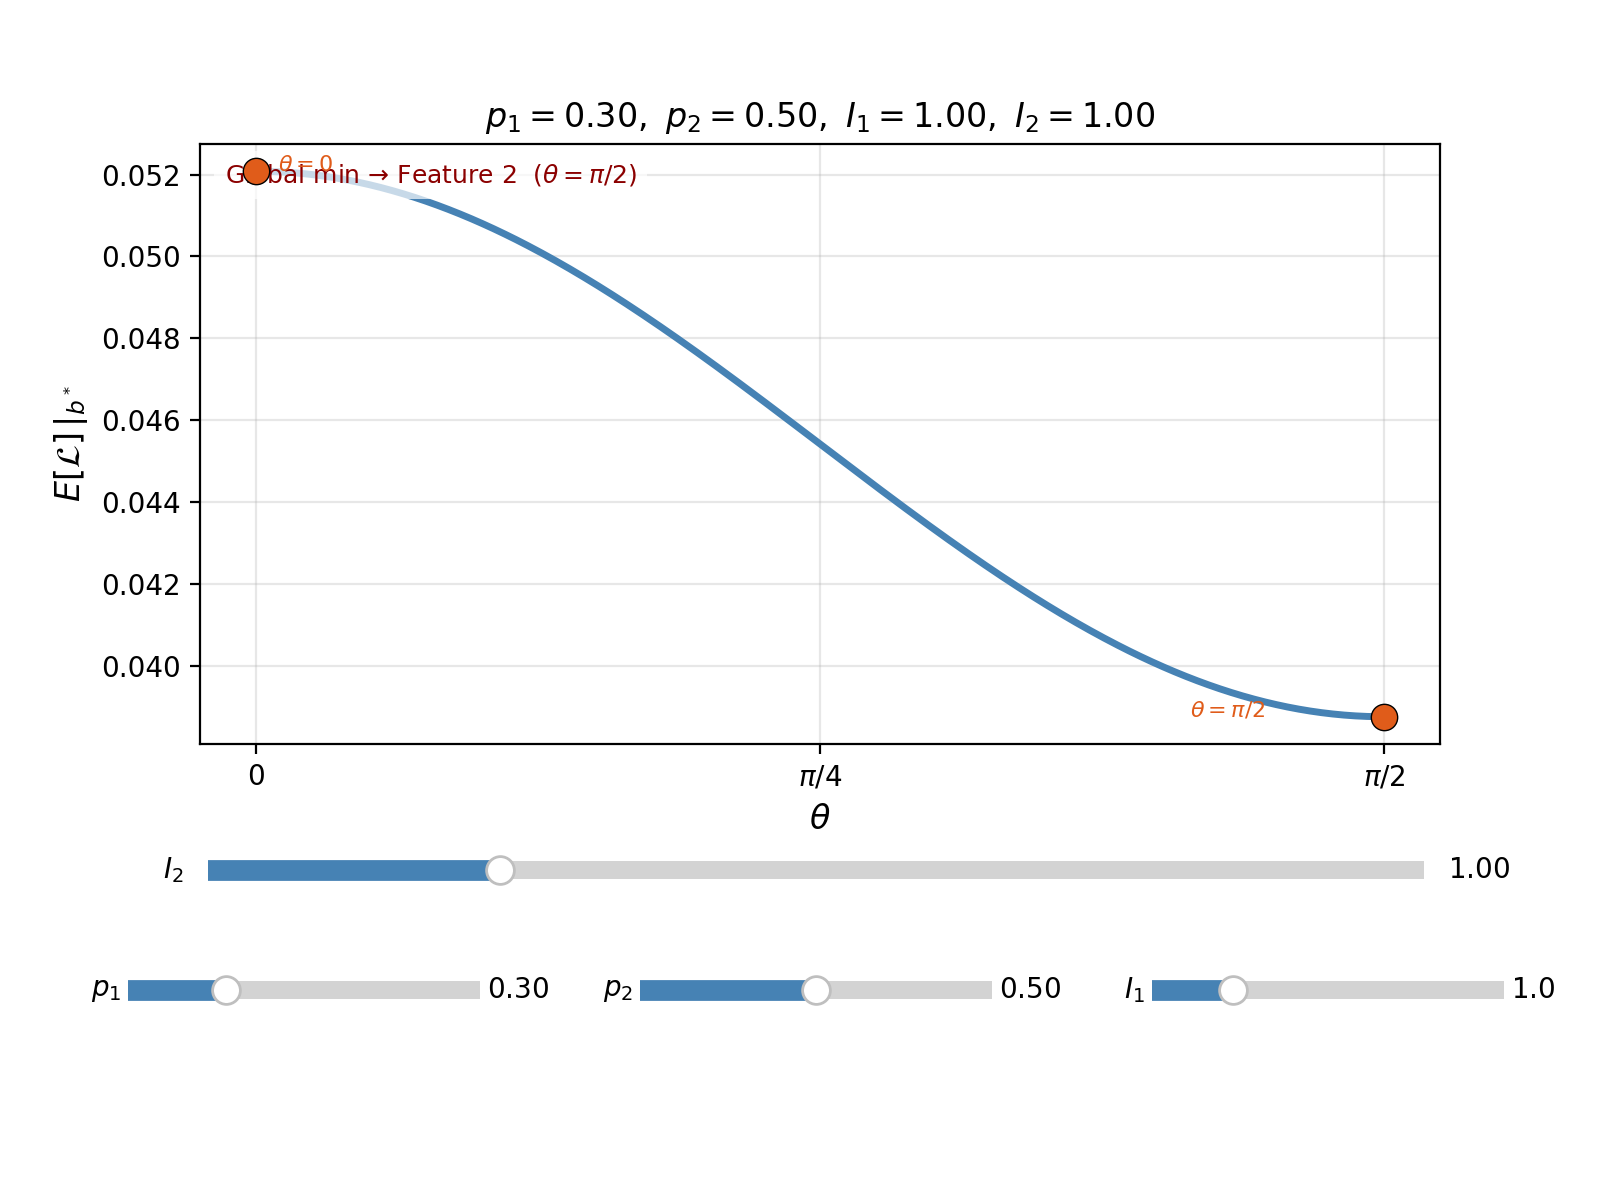

In [6]:

# =============================================================================
# 4. Dynamic plot: loss landscape as parameters vary
# =============================================================================
%matplotlib notebook

import matplotlib.pyplot as plt
import matplotlib.widgets as mwidgets
import numpy as np

thetas = np.linspace(0, np.pi/2, 400)

INIT   = dict(p1=0.3, p2=0.5, I1=1.0, I2=1.0)
I2_MIN, I2_MAX = 0.05, 4.0
P_MIN,  P_MAX  = 0.05, 0.95
I1_MIN, I1_MAX = 0.1,  4.0

fig, ax = plt.subplots(figsize=(8, 6))
plt.subplots_adjust(bottom=0.38)

y_init = E_L_opt(thetas, **INIT)
[curve] = ax.plot(thetas, y_init, 'steelblue', lw=2.5)

cp_scatter = ax.scatter([], [], zorder=5, s=90)
cp_texts   = []
phase_text = ax.text(0.02, 0.97, '', transform=ax.transAxes,
                     va='top', fontsize=9, color='darkred',
                     bbox=dict(fc='white', ec='none', alpha=0.7))

ax.set_xlabel(r'$\theta$', fontsize=12)
ax.set_ylabel(r'$E[\mathcal{L}]\,|_{b^*}$', fontsize=12)
ax.set_xticks([0, np.pi/4, np.pi/2])
ax.set_xticklabels(['$0$', r'$\pi/4$', r'$\pi/2$'])
ax.grid(alpha=0.3)
title_obj = ax.set_title('')

sl = {}
for key, rect, vmin, vmax, vinit, lbl, step in [
    ('I2', [0.13, 0.26, 0.76, 0.03], I2_MIN, I2_MAX, INIT['I2'], '$I_2$', 0.01),
    ('p1', [0.08, 0.16, 0.22, 0.03], P_MIN,  P_MAX,  INIT['p1'], '$p_1$', 0.05),
    ('p2', [0.40, 0.16, 0.22, 0.03], P_MIN,  P_MAX,  INIT['p2'], '$p_2$', 0.05),
    ('I1', [0.72, 0.16, 0.22, 0.03], I1_MIN, I1_MAX, INIT['I1'], '$I_1$', 0.05),
]:
    sl[key] = mwidgets.Slider(plt.axes(rect), lbl, vmin, vmax,
                              valinit=vinit, valstep=step, color='steelblue')

def redraw(val=None):
    global cp_scatter, cp_texts
    p1, p2, I1, I2 = sl['p1'].val, sl['p2'].val, sl['I1'].val, sl['I2'].val

    y = E_L_opt(thetas, p1, p2, I1, I2)
    curve.set_ydata(y)
    ax.relim();  ax.autoscale_view(scalex=False, scaley=True)

    cp_scatter.remove()
    for t in cp_texts: t.remove()
    cp_texts.clear()

    pts = [(0,       E_L_opt(0,       p1, p2, I1, I2), r'$\theta=0$'),
           (np.pi/2, E_L_opt(np.pi/2, p1, p2, I1, I2), r'$\theta=\pi/2$')]
    cp_scatter = ax.scatter([p[0] for p in pts], [p[1] for p in pts],
                            color='#e05c1a', zorder=6, s=90, edgecolors='k', lw=0.5)
    for th, lv, lbl in pts:
        cp_texts.append(ax.text(th + (0.03 if th == 0 else -0.27),
                                lv, lbl, fontsize=8, color='#e05c1a'))

    winner = r'Feature 1  ($\theta=0$)' if y[0] < y[-1] else r'Feature 2  ($\theta=\pi/2$)'
    phase_text.set_text(f'Global min → {winner}')
    title_obj.set_text(f'$p_1={p1:.2f},\\ p_2={p2:.2f},\\ I_1={I1:.2f},\\ I_2={I2:.2f}$')
    fig.canvas.draw_idle()

for key in sl:
    sl[key].on_changed(redraw)

redraw()
plt.show()


## 5–6. Phase diagrams

The global minimum — which feature is represented — is decided by comparing the loss at the two trivial critical points. At $\theta=0$ the network perfectly reconstructs feature 1, so the only loss comes from failing to reconstruct feature 2, and vice versa at $\theta=\pi/2$:

$$E[\mathcal{L}]\big|_{\theta=0} = I_2\,p_2\!\left(\tfrac{1}{6} - \tfrac{p_2}{8}\right), \qquad E[\mathcal{L}]\big|_{\theta=\pi/2} = I_1\,p_1\!\left(\tfrac{1}{6} - \tfrac{p_1}{8}\right).$$

Setting these equal gives the **exact phase boundary** in $(I_1, I_2)$ space:

$$\frac{I_2}{I_1} = \frac{p_1\!\left(1-\tfrac{3p_1}{4}\right)}{p_2\!\left(1-\tfrac{3p_2}{4}\right)}.$$

Section 5 checks this boundary against numerical minimisation for symmetric sparsity $p_1=p_2=0.4$; Section 6 uses $p_1=0.1$, $p_2=0.9$ to illustrate the boundary shift under asymmetric sparsity.

<IPython.core.display.Javascript object>


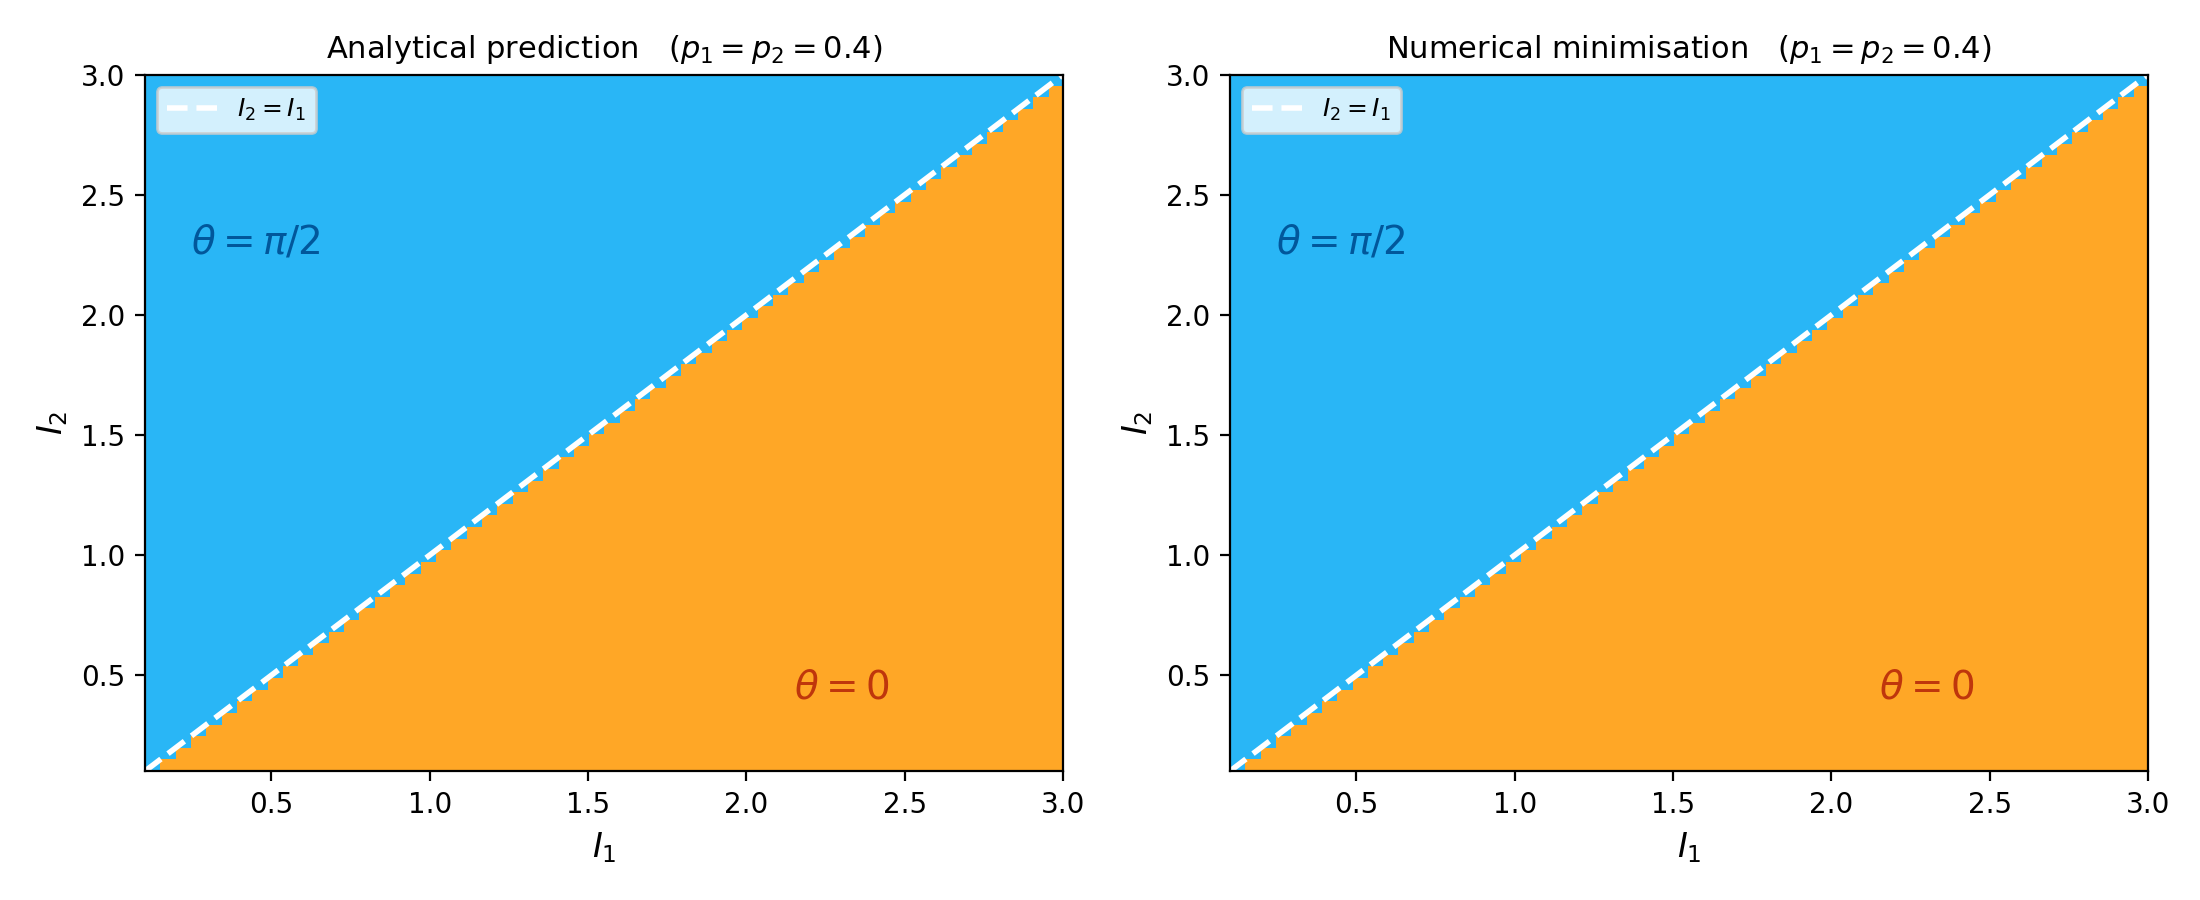

Agreement between analytical and numerical phase assignment: 100.0%


In [7]:

# =============================================================================
# 5. Phase diagram: which minimum (θ=0 or θ=π/2) wins?
# =============================================================================
import matplotlib.colors as mcolors
plt.close('all')

p  = 0.4
I1_vals = np.linspace(0.1, 3.0, 60)
I2_vals = np.linspace(0.1, 3.0, 60)

# winner[j, i] → row j = I2 index, col i = I1 index
# → imshow with origin='lower' gives x=I1, y=I2
winner_ana = np.zeros((60, 60))
winner_num = np.zeros((60, 60))

for i, I1 in enumerate(I1_vals):
    for j, I2 in enumerate(I2_vals):
        L0   = E_L_opt(0,       p, p, I1, I2)
        Lpi2 = E_L_opt(np.pi/2, p, p, I1, I2)
        winner_ana[j, i] = 1.0 if L0 < Lpi2 else 0.0   # 1 = feature 1 (θ=0)
        th_opt = minimize_1d(lambda t: E_L_opt(t, p, p, I1, I2), 0, np.pi/2)
        winner_num[j, i] = 1.0 if th_opt < np.pi/4 else 0.0

C_BLUE     = '#29B6F6'
C_ORANGE   = '#FFA726'
C_BLUE_D   = '#01579B'
C_ORANGE_D = '#BF360C'
cmap_phase = mcolors.ListedColormap([C_BLUE, C_ORANGE])   # 0→blue, 1→orange

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, W, title in zip(axes,
                         [winner_ana, winner_num],
                         ['Analytical prediction', 'Numerical minimisation']):
    ax.imshow(W, origin='lower',
              extent=[I1_vals[0], I1_vals[-1], I2_vals[0], I2_vals[-1]],
              aspect='auto', cmap=cmap_phase, vmin=0, vmax=1)
    ax.set_xlabel('$I_1$', fontsize=12)
    ax.set_ylabel('$I_2$', fontsize=12)
    ax.set_title(f'{title}   ($p_1 = p_2 = {p}$)', fontsize=11)

    # Boundary: I2 = I1 (diagonal)
    I_diag = np.linspace(0.1, 3.0, 200)
    ax.plot(I_diag, I_diag, 'w--', lw=2, label='$I_2 = I_1$')
    ax.legend(fontsize=9, loc='upper left')

    # In-region text labels (x=I1, y=I2)
    # θ=0 (orange): below diagonal, I2 < I1 → lower right
    ax.text(2.3, 0.45, r'$\theta = 0$', color=C_ORANGE_D,
            fontsize=14, fontweight='bold', ha='center', va='center')
    # θ=π/2 (blue): above diagonal, I2 > I1 → upper left
    ax.text(0.45, 2.3, r'$\theta = \pi/2$', color=C_BLUE_D,
            fontsize=14, fontweight='bold', ha='center', va='center')

plt.tight_layout()
plt.savefig('phase_diagram.png', dpi=120)
plt.show()

agree = np.mean(winner_ana == winner_num)
print(f"Agreement between analytical and numerical phase assignment: {agree:.1%}")


<IPython.core.display.Javascript object>


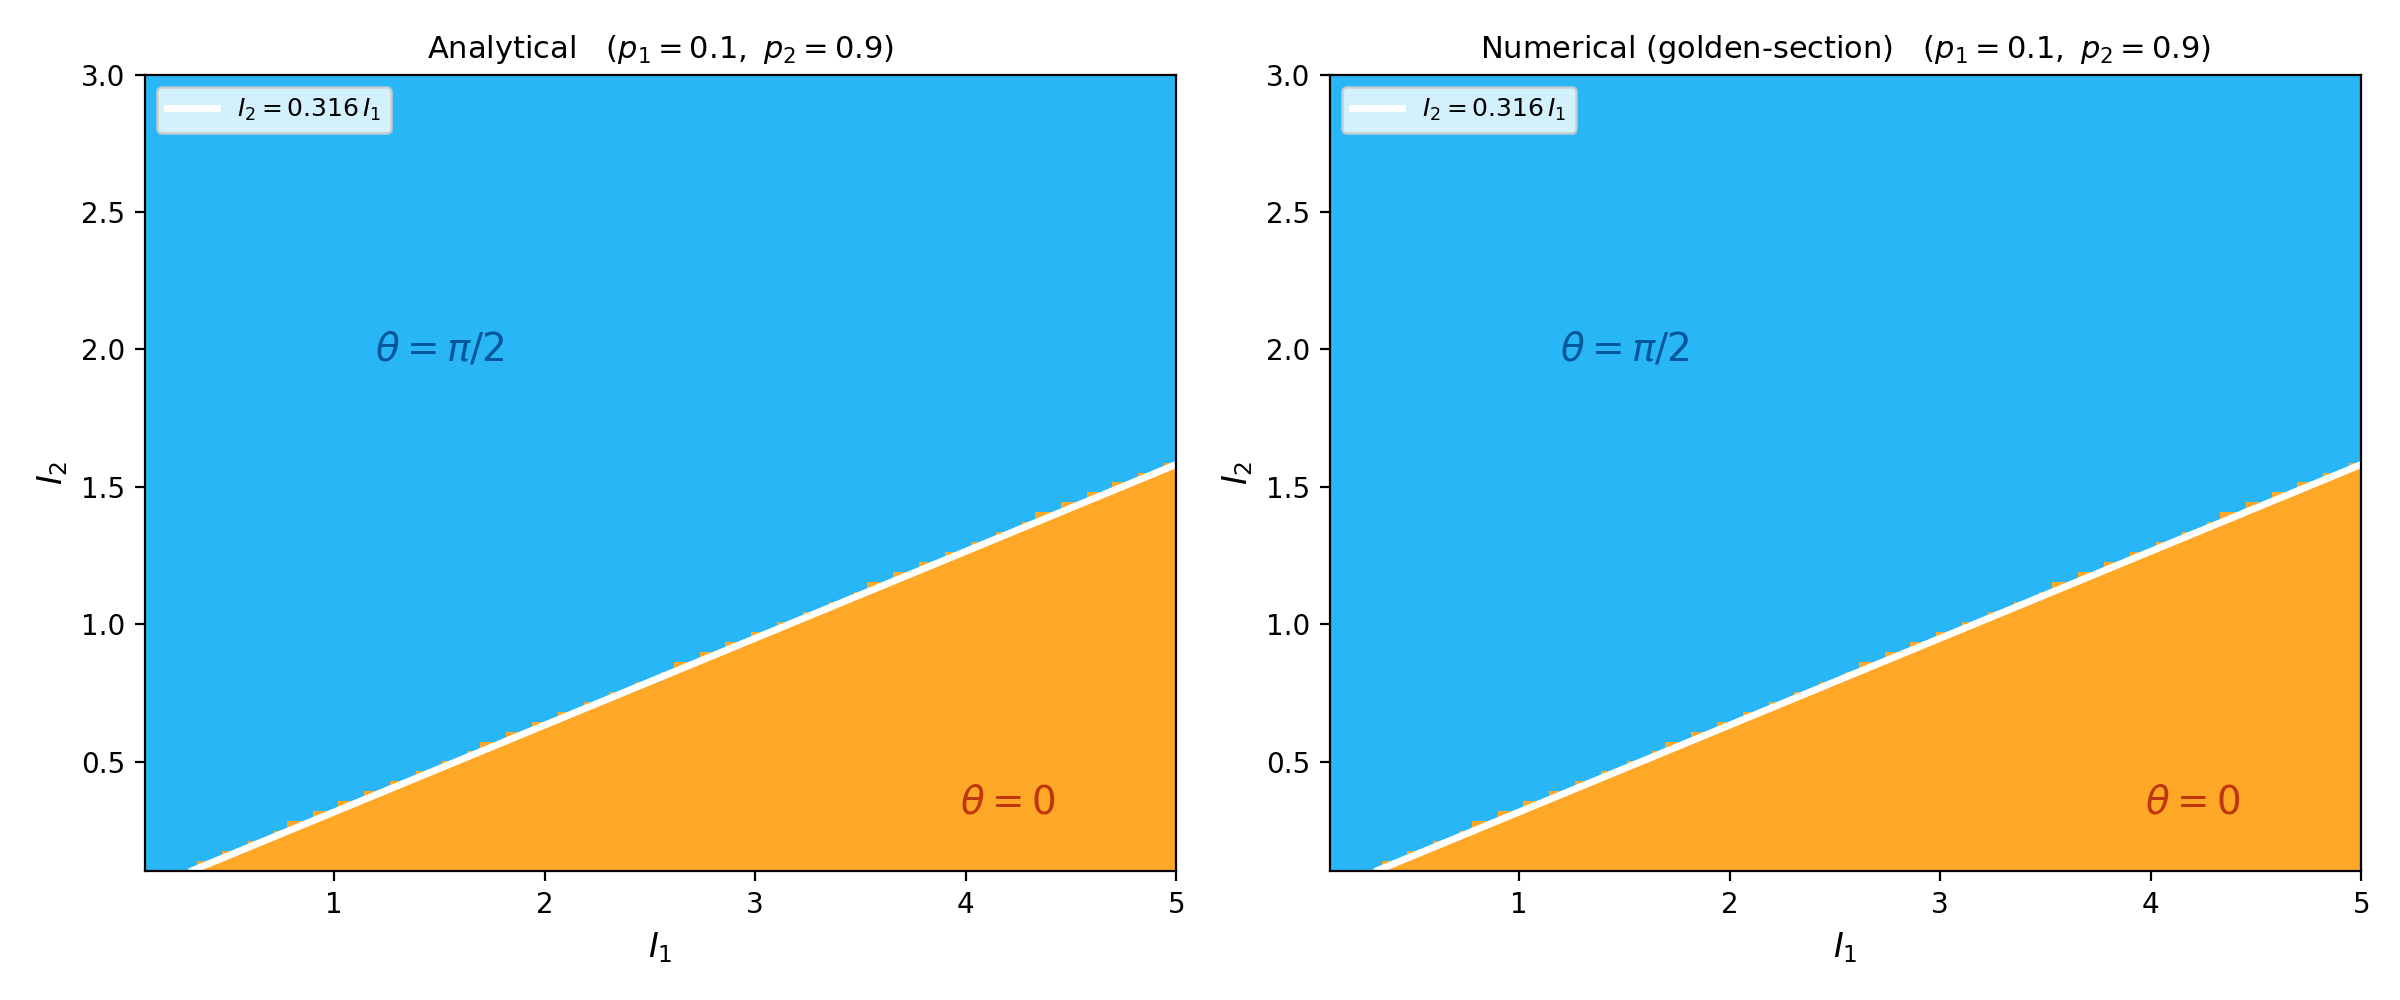

Agreement between analytical and numerical: 100.0%
Exact boundary slope I2/I1 = 0.3162


In [8]:

# =============================================================================
# 6. Phase plots with p1=0.1, p2=0.9: analytical vs numerical
# =============================================================================
import matplotlib.colors as mcolors
plt.close('all')

p1, p2 = 0.1, 0.9

I1_vals = np.linspace(0.1, 5.0, 80)
I2_vals = np.linspace(0.1, 3.0, 80)   # capped so the orange wedge is visible
I1_grid, I2_grid = np.meshgrid(I1_vals, I2_vals)

# ── analytical ────────────────────────────────────────────────────────────────
L0   = E_L_opt(0,       p1, p2, I1_grid, I2_grid)
Lpi2 = E_L_opt(np.pi/2, p1, p2, I1_grid, I2_grid)
winner_ana = (L0 < Lpi2).astype(float)   # 1 = feature 1 (θ=0), 0 = feature 2

# ── numerical (golden-section over θ) ────────────────────────────────────────
winner_num = np.zeros((80, 80))
for i, I1 in enumerate(I1_vals):
    for j, I2 in enumerate(I2_vals):
        th_opt = minimize_1d(lambda t: E_L_opt(t, p1, p2, I1, I2), 0, np.pi/2)
        winner_num[j, i] = 1.0 if th_opt < np.pi/4 else 0.0

# ── exact boundary  I2 = slope * I1 ─────────────────────────────────────────
slope_exact = (p1*(1/6 - p1/8)) / (p2*(1/6 - p2/8))
I1_line = np.linspace(0.1, 5.0, 300)
I2_exact = I1_line * slope_exact
mask = (I2_exact >= I2_vals[0]) & (I2_exact <= I2_vals[-1])

# Bright colours (same palette as section 5)
C_BLUE     = '#29B6F6'
C_ORANGE   = '#FFA726'
C_BLUE_D   = '#01579B'
C_ORANGE_D = '#BF360C'

cmap_phase = mcolors.ListedColormap([C_BLUE, C_ORANGE])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, W, title in zip(axes,
                         [winner_ana, winner_num],
                         ['Analytical', 'Numerical (golden-section)']):
    ax.imshow(W, origin='lower',
              extent=[I1_vals[0], I1_vals[-1], I2_vals[0], I2_vals[-1]],
              aspect='auto', cmap=cmap_phase, vmin=0, vmax=1)
    ax.set_xlabel('$I_1$', fontsize=12)
    ax.set_ylabel('$I_2$', fontsize=12)
    ax.set_title(f'{title}   ($p_1 = {p1},\\ p_2 = {p2}$)', fontsize=11)

    # Boundary line
    ax.plot(I1_line[mask], I2_exact[mask], 'w-', lw=2.5,
            label=f'$I_2 = {slope_exact:.3f}\\,I_1$')
    ax.legend(fontsize=9, loc='upper left')

    # In-region labels  (x = I1, y = I2)
    ax.text(1.5, 2.0, r'$\theta = \pi/2$', color=C_BLUE_D,
            fontsize=14, fontweight='bold', ha='center', va='center')
    ax.text(4.2, 0.35, r'$\theta = 0$',    color=C_ORANGE_D,
            fontsize=14, fontweight='bold', ha='center', va='center')

plt.tight_layout()
plt.savefig('phase_p01_p09.png', dpi=120)
plt.show()

agree = np.mean(winner_ana == winner_num)
print(f"Agreement between analytical and numerical: {agree:.1%}")
print(f"Exact boundary slope I2/I1 = {slope_exact:.4f}")


## Summary

This notebook numerically verifies the analytical results derived in the accompanying write-up for the **linear toy model of superposition** (1-hidden-unit autoencoder, 2 features, sparse inputs).

| Section | What is verified |
|:---|:---|
| **1. E[L] validation** | Monte Carlo estimates of $E[\mathcal{L}]$ match the closed-form expression across a grid of $(\theta, b_1, b_2)$ values. |
| **2. Optimal biases $b^*$** | Numerical minimisation of $E[\mathcal{L}]$ over $(b_1, b_2)$ recovers the analytical $b^*(\theta)$ to high precision; relative errors are reported at each $\theta$. |
| **3. Loss landscape & convergence** | The reduced loss $E[\mathcal{L}]\big|_{b^*}(\theta)$ is plotted analytically and estimated via MC at three sample sizes (5k / 50k / 500k), confirming $1/\sqrt{k}$ convergence and showing no interior minima. |
| **4. Dynamic plot** | Interactive sliders let you vary $I_2$, $p_1$, $p_2$, $I_1$ and see the loss landscape update in real time. Requires running locally. |
| **5. Phase diagram (symmetric)** | Phase diagram in $(I_1, I_2)$ space for $p_1 = p_2 = 0.4$: the exact boundary $I_2/I_1 = 1$ correctly separates the two phases. |
| **6. Phase diagram (asymmetric)** | Phase diagram for $p_1 = 0.1$, $p_2 = 0.9$: the exact boundary $I_2/I_1 \approx 0.316$ is validated numerically. |

**Key finding:** In the linear model, gradient descent never finds superposition — the optimal solution always represents exactly one feature, and the apparent interior critical point $\theta^*$ is always a saddle.